In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('..')

In [5]:
from src.robin.scraping.entities import DataLoader, SupplySaver

import_path = '../data/renfe'
trips_path = f'{import_path}/stop_times/stopTimes_MADRI_BARCE_2023-06-01_2023-06-02.csv'

In [6]:
data_loader = DataLoader(trips_path, renfe_stations_path='../data/renfe/renfe_stations.csv')
data_loader.show_metadata()

Origin:MADRI - Destination:BARCE
Since: 2023-06-01, Until: 2023-06-02


In [7]:
data_loader.build_supply_entities()
print(data_loader.services[0])

services = data_loader.services
SupplySaver(services).to_yaml(filename='supply_data_ewgt23.yml', save_path='../configs/thesis/')

Service id: 06301_01-06-2023-06.15 
	Date of service: 2023-06-01 
	Stops: ['60000', '71801'] 
	Line times (relative): [(0, 0), (150, 150)] 
	Line times (absolute): [('06:15', '06:15'), ('08:45', '08:45')] 
	Train Service Provider: [1, Renfe, ['1']] 
	Time Slot: [37510, 6:15:00, 6:25:00, 6:20:00, 0:10:00] 
	Rolling Stock: [1, S-114, {1: 250, 2: 50}] 
	Prices: 
		('60000', '71801'): {Basico: 15.0} 
	Tickets sold (seats): {Basico: 0} 
	Tickets sold (hard type): {1: 0, 2: 0} 
	Tickets sold per each pair (seats): {('60000', '71801'): {Basico: 0}} 
	Tickets sold per each pair (hard type): {('60000', '71801'): {1: 0}} 
	Capacity constraints: None 


In [8]:
time_slots = list(data_loader.time_slots.values())

In [9]:
departure_times = [ts.class_mark.seconds for ts in time_slots]

departure_times

[22800,
 23700,
 25500,
 27300,
 29100,
 30900,
 32700,
 34500,
 38100,
 41700,
 45300,
 47100,
 48600,
 52500,
 54300,
 56100,
 57900,
 59700,
 61500,
 63300,
 65100,
 66900,
 68700,
 70500,
 72300,
 74700,
 76500]

In [11]:
print(len(departure_times))

27


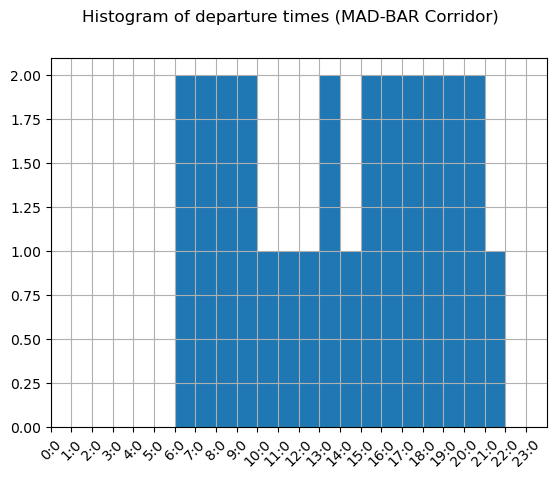

In [10]:
from datetime import datetime
from matplotlib import pyplot as plt

# Plot histogram of departure times
#convert strings into datetime objects

#define bin number
bin_nr = 7
fig, ax = plt.subplots(1,1)

fig.suptitle('Histogram of departure times (MAD-BAR Corridor)')

#create histogram, get bin position for label
bins = [i for i in range(0, 24*60*60, 60*60)]
_counts, bins, _patches = ax.hist(departure_times, bins = bins)

ax.set_xlim([0, 24*60*60])
#set xticks at bin edges
plt.xticks(ticks=bins,
           labels=[f'{int(b // (60 * 60))}:{int(b % (60*60))}' for b in bins],
           rotation=45)

plt.grid()

plt.show()
fig.savefig('../reports/figures/dt_histogram.png', dpi=300)

In [12]:
len(services)

27

In [6]:
from src.robin.supply.entities import Supply

from pathlib import Path

supply = Supply.from_yaml(path=Path('../configs/thesis/supply_data.yml'))

In [7]:
SupplySaver(supply.services).to_yaml(filename='supply_data_new.yml', save_path='../configs/thesis/')